In [12]:
'Random Forest Classifier'

# repeat same preprocessing steps as linear_svm implementation

import numpy as np
import pandas as pd

pd.set_option('display.width', 1000)        # keeps all the features on one line

df = pd.read_csv('wildfires_training.csv')  # read data in from csv using pandas dataframe
print("Training Data in pandas array:\n", df)

tf = pd.read_csv('wildfires_test.csv')      # add in testing dataset same as training
print("\nTest Data in pandas:\n", tf)

training_data = df.to_numpy()               # convert data from 2D array numpy array
test_data = tf.to_numpy()

print("\nTraining Data in numpy array:\n", training_data)
print("\nTest Data in numpy array:\n", test_data)

y_train = training_data[:,0]
print("(y_train)Targets:\n", y_train)

X_train = training_data[:,1:]
print("\n(X_train)Features:\n", X_train)

# separate X and y in test data as well
y_test = test_data[:,0]
X_test = test_data[:,1:]

Training Data in pandas array:
     fire  year  temp  humidity  rainfall  drought_code  buildup_index  day  month  wind_speed
0     no  2015    28        59       0.0          8.06           3.47    1      6          19
1     no  2010    30        61       1.3          8.17           4.03    2      6          13
2     no  2009    26        83      13.1          8.08           3.59    3      6          22
3     no  2017    25        87       2.5          7.18           2.42    4      6          15
4     no  2014    28        77       0.0         14.98           4.63    5      6          18
..   ...   ...   ...       ...       ...           ...            ...  ...    ...         ...
149  yes  2017    31        67       0.0         45.15          17.89   26      9          15
150   no  2017    29        89       4.4          8.74           6.52   27      9          15
151   no  2009    27        88       0.5          8.87           3.71   28      9          30
152   no  2016    25        

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# import and run default RFC and gather prediction accuracy
default_clf = RandomForestClassifier(random_state=42)

default_clf.fit(X_train, y_train)

default_prediction = default_clf.predict(X_test)
default_accuracy = accuracy_score(y_test, default_prediction)
print(default_accuracy)

0.84


In [22]:
# for loop to run through combinations of hyperparameters for RFC and record their accuracy on training dataset
from sklearn.model_selection import train_test_split

X_train_small, X_val, y_train_small, y_val = train_test_split(X_train, y_train, stratify=y_train, test_size=0.25)

best_score = 0

# loop through large range of potential max depths and min leaf node hp values
for n_estimator_search in range(100, 550, 50):
    for max_features_search in [None, .1, .2, .3, .4, .5, 1, 4, 6, 8, 10]:

        hyper_tuned_clf = RandomForestClassifier(n_estimators=n_estimator_search, max_features=max_features_search, random_state=42)         # apply range of hp's to new classifier
        hyper_tuned_clf.fit(X_train_small, y_train_small)                                                                               # fit clf to the training dataset

        y_prediction = hyper_tuned_clf.predict(X_val)                                             # make predictions on training data using each parameter combo
        validation_accuracy = accuracy_score(y_val, y_prediction)                                 # get accuracy score of each hp
        #print(f"n_estimator={n_estimator_search}, max_features={max_features_search}, Accuracy={validation_accuracy}")

        # compare accuracy scores and print out the highest hp inputs
        if validation_accuracy >= best_score:
            best_score = validation_accuracy
            print(f" BEST ACCURACY SCORE: n_estimator={n_estimator_search}, max_features={max_features_search}, Validation Accuracy={validation_accuracy}")

            best_params = [n_estimator_search, max_features_search]


 BEST ACCURACY SCORE: n_estimator=100, max_features=None, Validation Accuracy=0.8717948717948718
 BEST ACCURACY SCORE: n_estimator=100, max_features=0.1, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=100, max_features=0.2, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=100, max_features=0.5, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=100, max_features=1, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=100, max_features=4, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=150, max_features=0.1, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=150, max_features=0.2, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=150, max_features=0.3, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=150, max_features=0.5, Validation Accuracy=0.9230769230769231
 BEST ACCURACY SCORE: n_estimator=150, max_

In [15]:


improved_rfc = RandomForestClassifier(n_estimators=best_params[0], max_features=best_params[1], random_state=42)
improved_rfc.fit(X_train, y_train)
actual_y_predictions = improved_rfc.predict(X_test)

improved_accuracy = accuracy_score(y_test, actual_y_predictions)
print(improved_accuracy)

0.86


In [16]:
print(f"Default Accuracy: {default_accuracy} vs  Tuned Model Accuracy: {improved_accuracy}")

Default Accuracy: 0.84 vs  Tuned Model Accuracy: 0.86


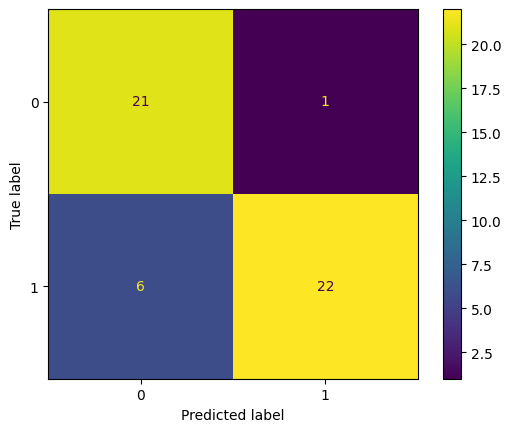

              precision    recall  f1-score   support

          no       0.78      0.95      0.86        22
         yes       0.96      0.79      0.86        28

    accuracy                           0.86        50
   macro avg       0.87      0.87      0.86        50
weighted avg       0.88      0.86      0.86        50



In [ ]:
# confusion matrix and classification report for comparative analysis
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

confusion_matrix = confusion_matrix(y_test, actual_y_predictions)

cm_display = ConfusionMatrixDisplay(confusion_matrix = confusion_matrix, display_labels = [0, 1])

cm_display.plot()
plt.show()

report = classification_report(y_test, actual_y_predictions)
print(report)

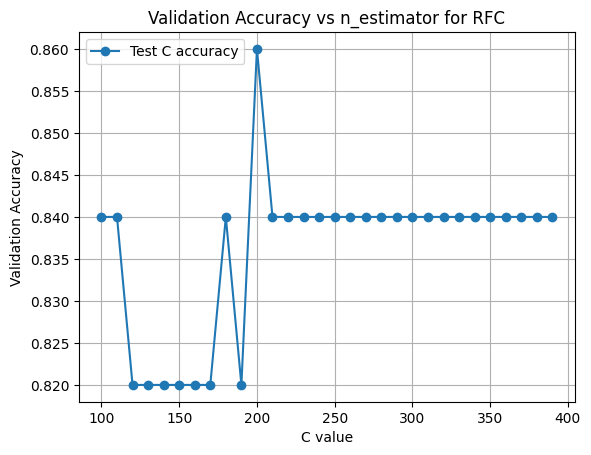

In [ ]:

# arrays made to store values of accuracy and C ran on the Test set
estimator_values_acc = []
accuracies_acc = []

# loop through range of C values and get their predictions on the training set - append value of n_estimators and accuracy to related array
for n_estimator_search in range(100,400, 10):

    improved_clf = RandomForestClassifier(n_estimators=n_estimator_search, random_state=42)
    improved_clf.fit(X_train, y_train)
    y_improved_prediction = improved_clf.predict(X_test)
    improved_accuracy = accuracy_score(y_test, y_improved_prediction)
    
    estimator_values_acc.append(n_estimator_search)
    accuracies_acc.append(improved_accuracy)
    

# plot the coords for both arrays to get accuracy graph relative to C value chosen
plt.plot(estimator_values_acc, accuracies_acc, marker='o', label="Test C accuracy")
plt.xlabel('C value')
plt.ylabel('Validation Accuracy')
plt.title('Validation Accuracy vs n_estimator for RFC')
plt.legend(loc="upper left")
plt.grid(True)
plt.show()